In [18]:
# Time series data is data indexed in time order, typically collected at regular intervals. It shows how things change at different points, like stock prices every day or temperature every hour.

# It is used in industries such as finance, pharmaceuticals, social media and research.
# Analyzing and visualizing this data helps us find trends, seasonal patterns and behaviors.
# These insights support forecasting and guide better decision-making.
# The main goal is to study data in time order to extract meaningful patterns and predictions.
# Concepts in Time Series Analysis
# Trend: Long-term direction of data (increasing, decreasing, or stable).
# Seasonality: Repeating patterns at regular intervals.
# Moving average: Smooths short-term fluctuations to highlight trends.
# Noise: Random variations without a clear pattern.
# Differencing: Computes difference between values at a given interval.
# Stationarity: A time series whose statistical properties (mean, variance, autocorrelation) remain constant over time.
# Order: The order of differencing refers to the number of times the time series data needs to be differenced to achieve stationarity.
# Autocorrelation: Autocorrelation is a statistical method used in time series analysis to quantify the degree of similarity between a time series and a lagged version of itself.
# Resampling: Resampling is a technique in time series analysis that is used for changing the frequency of the data observations.
# Types of Time Series Data
# Time series data is defined by time-based indexing rather than being strictly continuous or discrete. It can contain both continuous and discrete values depending on the dataset.

# Continuous Time Series: Data recorded at regular intervals with a continuous range of values like temperature, stock prices, Sensor Data, etc.
# Discrete Time Series: Data with distinct values or categories recorded at specific time points like counts of events, categorical statuses, etc.
# Visualization Approaches
# Use line plots or area charts for continuous data to highlight trends and fluctuations.
# Use bar charts or histograms for discrete data to show frequency or distribution across categories.
# Practical Time Series Visualization with Python

In [19]:
# Step 1: Installing and Importing Libraries
# We will be using Numpy, Pandas, seaborn and Matplotlib libraries.
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller

In [20]:
# Step 2: Loading the Dataset
# Here we will load the dataset and use the parse_dates parameter to convert the Date column to the DatetimeIndex format.

df = pd.read_csv("stock_data.csv",
                 parse_dates=True,
                 index_col="Date")
df.head()

,Unnamed: 0,Open,High,Low,Close,Volume,Name
Date,,,,,,,
2006-01-03,NaN,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,NaN,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,NaN,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,NaN,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,NaN,43.10,43.66,42.82,43.42,16268338,AABA


In [21]:
# Step 3: Cleaning of Data
# We will drop columns from the dataset that are not important for our visualization.

df.drop(columns='Unnamed: 0', inplace =True)
df.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


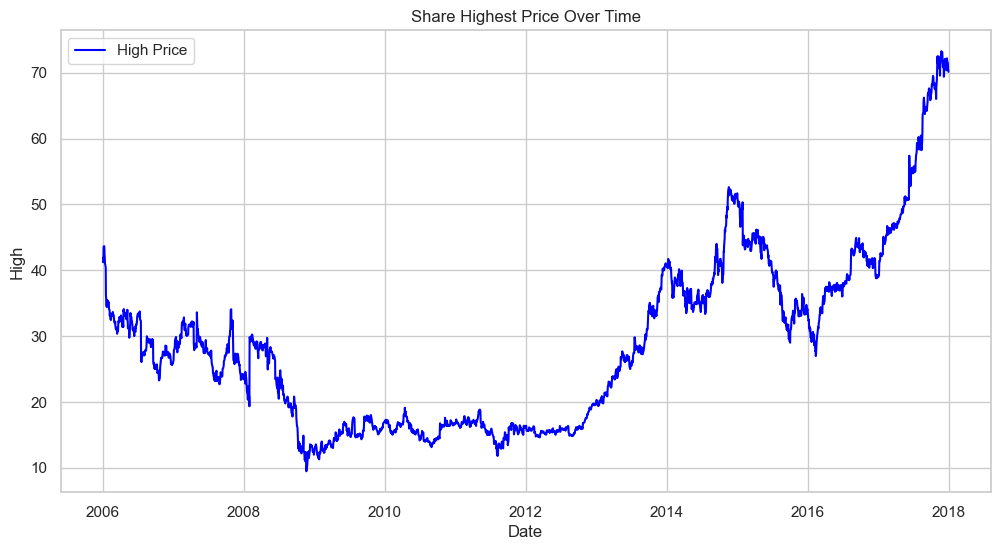

In [22]:
# Step 4: Plotting High Stock Prices
# Since the 'High'column is of continuous data type we will use line graph to visualize it.

# sns.lineplot(data=df, x=df.index, y='High', label='High Price', color='blue'): Plots High prices over time using the datetime index on x-axis.

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df, x='Date', y='High', label='High Price', color='blue')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Share Highest Price Over Time')

plt.show()

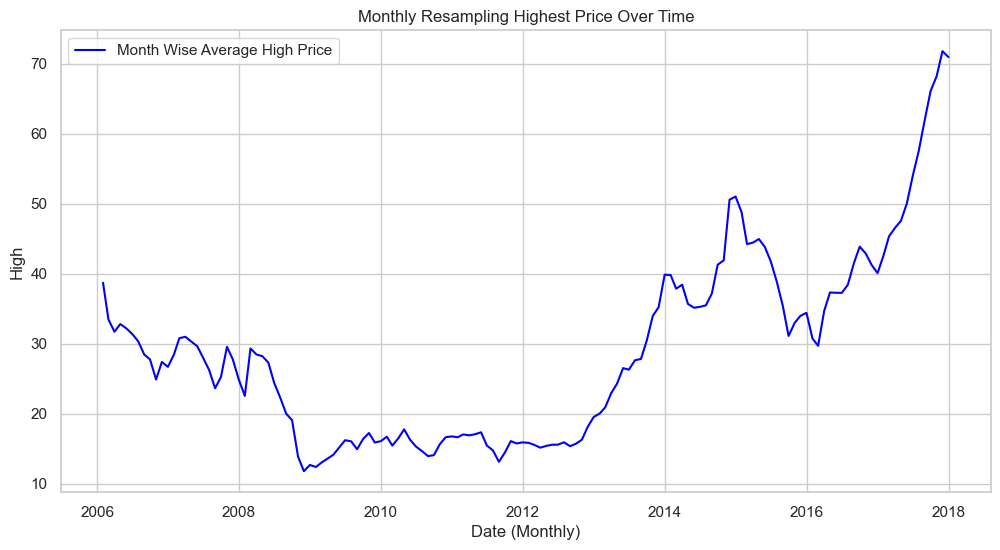

In [23]:
# Step 5: Resampling Data
# To better understand the trend of the data we will use the resampling method which provide a clearer view of trends and patterns when we are dealing with daily data.

# df_resampled = df.resample('ME').mean(numeric_only=True): Resamples data to monthly frequency and calculates the mean of all numeric columns for each month.

df_resampled = df.resample('ME').mean(numeric_only=True)

sns.set(style="whitegrid")

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_resampled, x=df_resampled.index, y='High', label='Month Wise Average High Price', color='blue')

plt.xlabel('Date (Monthly)')
plt.ylabel('High')
plt.title('Monthly Resampling Highest Price Over Time')

plt.show()

'Date' is already the index or not present in the DataFrame.


<Figure size 1200x600 with 0 Axes>

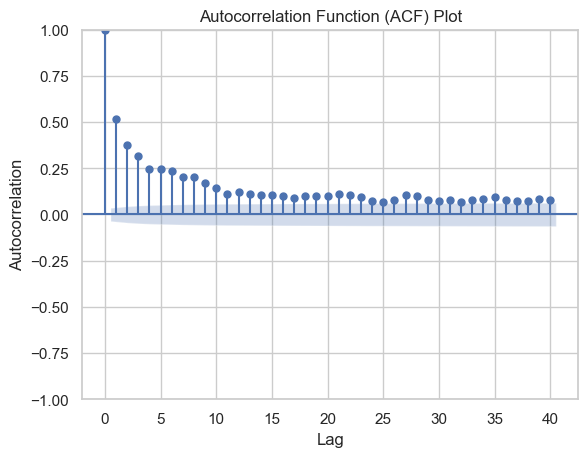

In [24]:
# Step 6: Detecting Seasonality with Autocorrelation
# We will detect Seasonality using the autocorrelation function (ACF) plot. Peaks at regular intervals in the ACF plot suggest the presence of seasonality.

if 'Date' not in df.columns:
    print("'Date' is already the index or not present in the DataFrame.")
else:
    df.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
plot_acf(df['Volume'], lags=40)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.title('Autocorrelation Function (ACF) Plot')
plt.show()

In [25]:
# Step 7: Testing Stationarity with ADF test
# We will perform the ADF test to formally test for stationarity.

from statsmodels.tsa.stattools import adfuller

result = adfuller(df['High'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

# Based on the ADF Statistic we accept the null hypothesis, 
# indicating that the data is not stationary according to the Augmented Dickey-Fuller test.
# This suggests that differencing or other transformations may be needed 
# to achieve stationarity before applying certain time series models.

ADF Statistic: 0.7671404880535935
p-value: 0.9910868050318213
Critical Values: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}


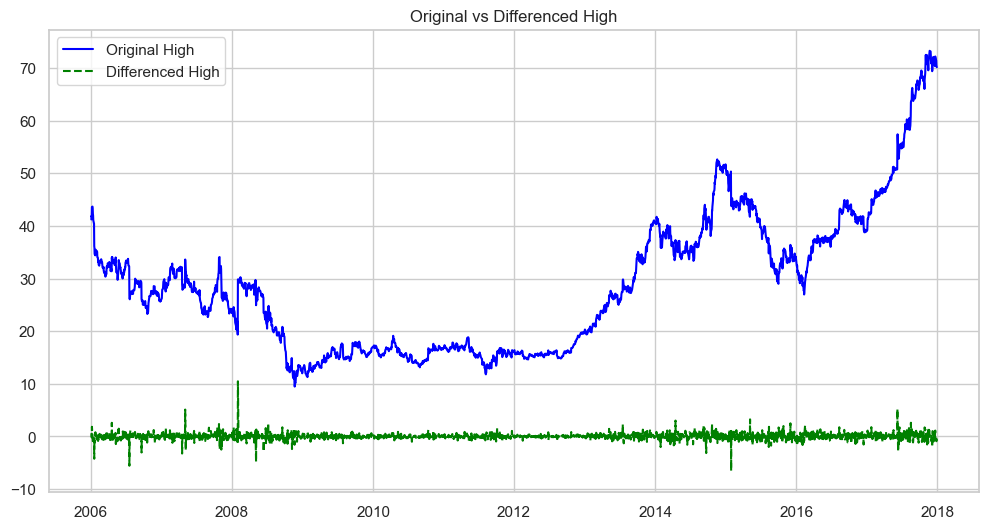

In [26]:
# Step 8: Differencing to Achieve Stationarity
# Differencing involves subtracting the previous observation from the current observation to remove trends or seasonality.

df['high_diff'] = df['High'].diff()

plt.figure(figsize=(12, 6))
plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_diff'], label='Differenced High', linestyle='--', color='green')
plt.legend()
plt.title('Original vs Differenced High')
plt.show()

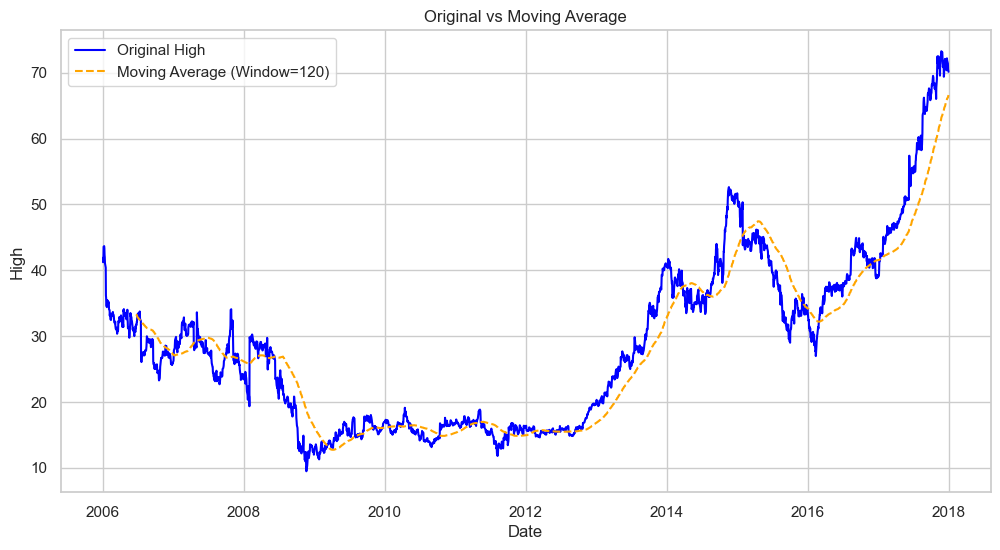

In [27]:
# Step 9: Smoothing Data with Moving Average
# df['High'].diff(): helps in calculating the difference between consecutive values in 
# the High column. This differencing operation is used to transform a time series into a new series 
# that represents the changes between consecutive observations.

window_size = 120
df['high_smoothed'] = df['High'].rolling(window=window_size).mean()

plt.figure(figsize=(12, 6))

plt.plot(df['High'], label='Original High', color='blue')
plt.plot(df['high_smoothed'], label=f'Moving Average (Window={window_size})', linestyle='--', color='orange')

plt.xlabel('Date')
plt.ylabel('High')
plt.title('Original vs Moving Average')
plt.legend()
plt.show() 

# This calculates the moving average of the High column with a window size of 120(A quarter), 
# creating a smoother curve in the high_smoothed series. 
# The plot compares the original High values with the smoothed version.

In [28]:
# Step 10: Original Data vs. Differenced Data
# Printing the original and differenced data side by side we get:

df_combined = pd.concat([df['High'], df['high_diff']], axis=1)

print(df_combined.head())

             High  high_diff
Date                        
2006-01-03  41.22        NaN
2006-01-04  41.90       0.68
2006-01-05  41.73      -0.17
2006-01-06  43.57       1.84
2006-01-09  43.66       0.09


In [29]:
# Hence the high_diff column represents the differences between consecutive high values. 
# The first value of high_diff is NaN because there is no previous value 
# to calculate the difference.
# As there is a NaN value we will drop that proceed with our test:

df.dropna(subset=['high_diff'], inplace=True)
df['high_diff'].head()

Date
2006-01-04    0.68
2006-01-05   -0.17
2006-01-06    1.84
2006-01-09    0.09
2006-01-10   -0.32
Name: high_diff, dtype: float64

In [30]:
#the ADF test:

from statsmodels.tsa.stattools import adfuller

result = adfuller(df['high_diff'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -12.148367478343276
p-value: 1.591276613414641e-22
Critical Values: {'1%': np.float64(-3.4325316347197403), '5%': np.float64(-2.862503905260741), '10%': np.float64(-2.5672831121111113)}


In [31]:
# Since the p-value is less than 0.05, 
# we reject the null hypothesis and conclude that the series is stationary.